# 专家系统

## 专家系统是最早的通用人工智能系统
- 什么是专家系统？
    - 将人类专家的领域知识转化为形式化的知识库模型
    - 依托基础逻辑推导规则开展推理运算
    - 以此模拟人类专家的推理思路与决策过程
- 专家系统面临的诸多现实困难，推动人们转向基于统计理论的机器学习方法。

## 专家系统的组成
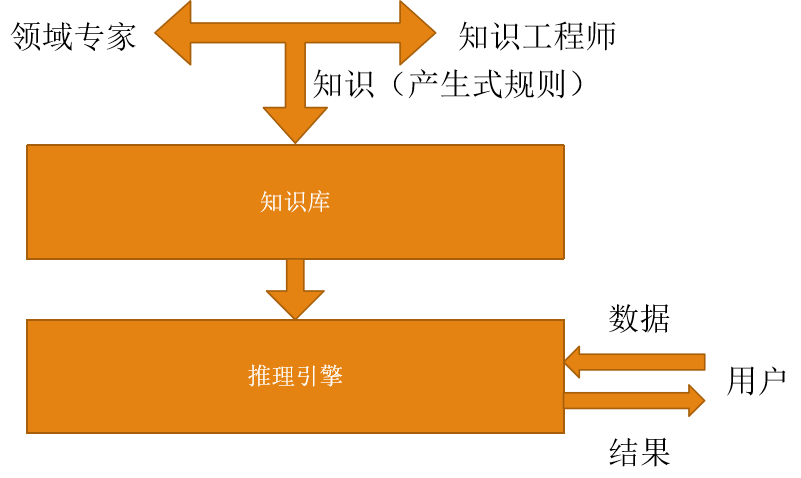

## 动物识别专家系统

### 正向推理
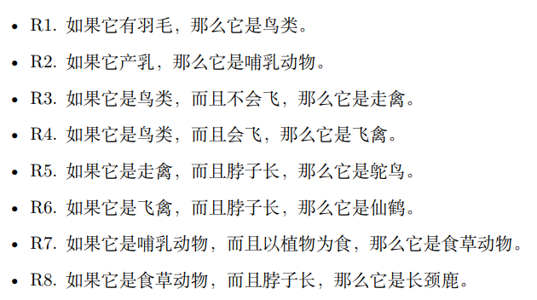

## 

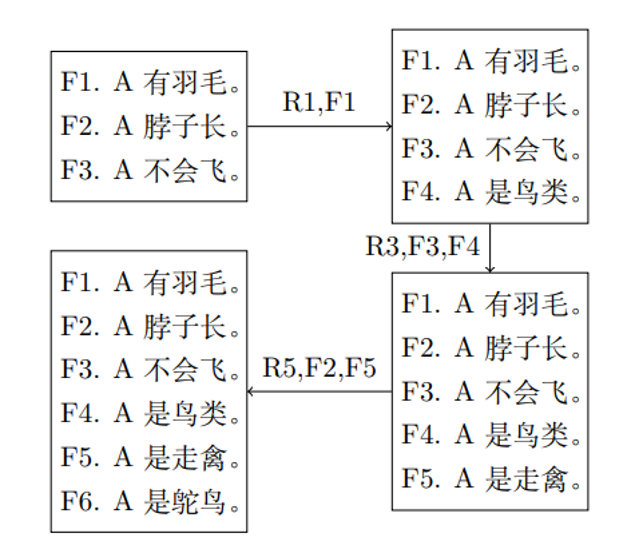

In [4]:
# 定义产生式规则
rules = ['有羽毛 => 鸟类',
    '产乳 => 哺乳动物',
    '鸟类 and 会飞行 => 飞禽',
    '飞禽 and 脖子长 => 仙鹤',
    '哺乳动物 and 吃草 => 食草动物',
    '食草动物 and 脖子长 => 长颈鹿']

# 解析规则
def parse_rules(rules):
    parsed_rules = []
    for rule in rules:
        conditions, result = rule.split(' => ')
        conditions = conditions.split(' and ')
        parsed_rules.append((conditions, result))
    return parsed_rules

parse_rules(rules)

[(['有羽毛'], '鸟类'),
 (['产乳'], '哺乳动物'),
 (['鸟类', '会飞行'], '飞禽'),
 (['飞禽', '脖子长'], '仙鹤'),
 (['哺乳动物', '吃草'], '食草动物'),
 (['食草动物', '脖子长'], '长颈鹿')]

In [2]:
# 正向推理过程，以规则和事实为输入
def forward_chain(rules, facts):
    has_new_fact = True  # 标记是否产生新事实
    # 循环推理：只要有新事实，就继续匹配规则
    while has_new_fact:
        has_new_fact = False  # 初始化为无新事实
        for rule in rules:
            # 检查当前规则的所有条件是否都在已知事实中
            condition_met = all([x in facts for x in rule[0]])
            if not condition_met:  # 条件不满足，跳过该规则
                continue
            # 若结论未在事实中，说明推导出新事实
            has_new_fact = rule[1] not in facts
            if has_new_fact:
                facts.append(rule[1])  # 新事实加入事实库
                print(rule[1])  # 打印推导的新事实
                break  # 找到新事实后重新循环（避免漏匹配）

forward_chain(parse_rules(rules), ['会飞行','有羽毛','脖子长'])

鸟类
飞禽
仙鹤


推理过程分步解析：
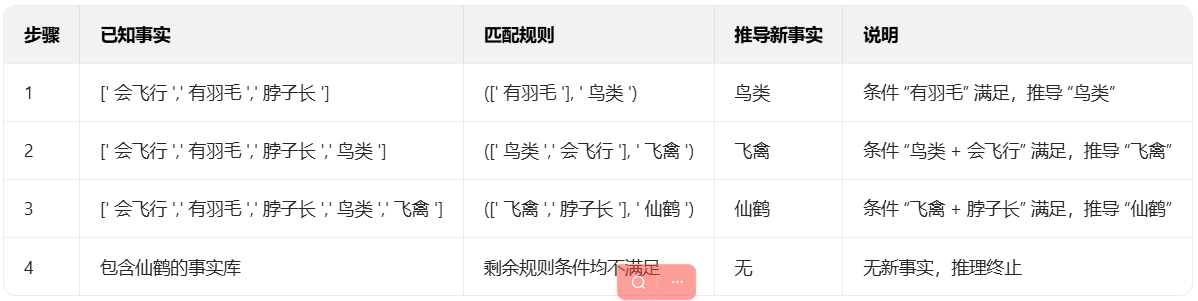

### 逆向推理
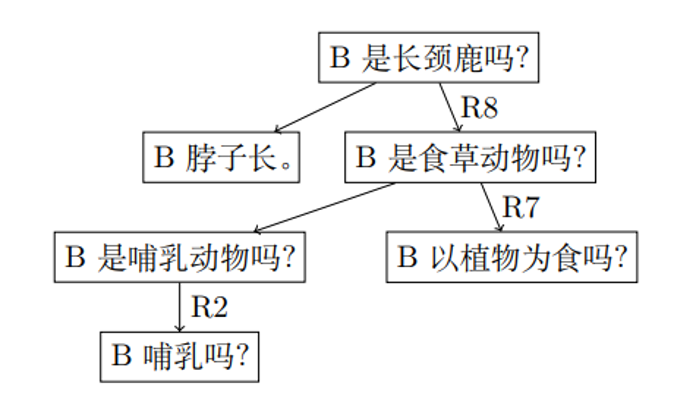

In [3]:
# 反向推理过程，以规则、事实和假设的目标为输入
def backward_chain(rules, facts, hypo):
    # 终止条件1：假设已在事实中，无需验证
    if hypo in facts:
        return
    some_rule_applies = False  # 标记是否有规则能推导该假设
    for rule in rules:
        if rule[1] != hypo:  # 规则结论≠假设，跳过
            continue
        some_rule_applies = True  # 找到能推导假设的规则
        # 检查该规则的条件是否都满足
        condition_met = all([x in facts for x in rule[0]])
        if condition_met:  # 条件满足，假设成立，加入事实
            facts.append(rule[1])
            return
        # 条件不满足，递归验证每个未满足的条件
        for fact in rule[0]:
            if fact in facts:  # 条件已满足，跳过
                continue
            backward_chain(rules, facts, fact)  # 递归验证子条件
    # 终止条件2：无规则能推导假设，需用户求证
    if not some_rule_applies:
        print('{0}?'.format(hypo))

backward_chain(parse_rules(rules), ['脖子长'], '长颈鹿')

产乳?
吃草?


推理过程分步解析：

目标假设：长颈鹿
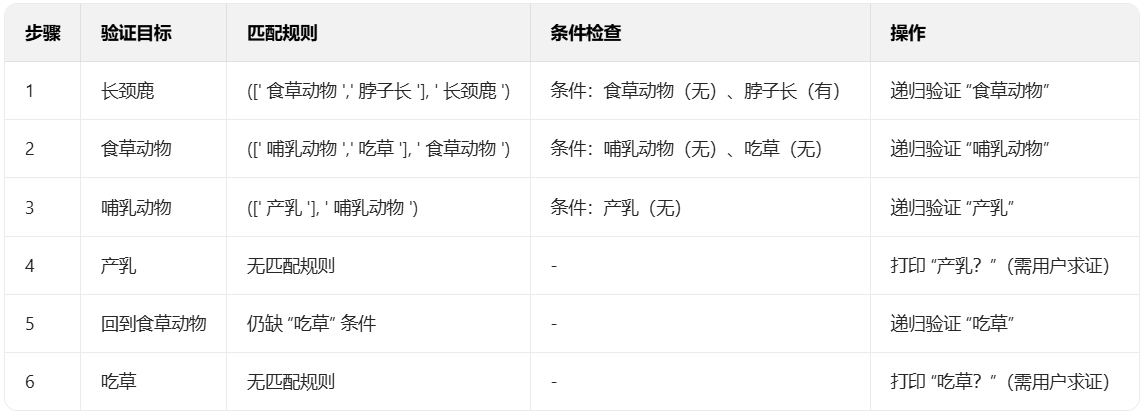

## 专家系统的核心挑战
- 知识获取难题
    - 领域专家时间成本高昂，难以持续投入知识库构建
    - 需知识工程师与领域专家协作完成知识录入，沟通成本高
    - 知识库的一致性、完备性难以保障，易出现歧义与冲突
- 系统性能瓶颈
    - 早期系统多基于LISP等语言开发，解释执行模式效率低下
    - 面对大规模规则库时，响应速度与运行稳定性无法满足实际需求
- 计算复杂度困境
    - 规则验证本质为NP完全问题，随着规则数量增加
    - 计算复杂度呈指数级增长，远超实际应用的可接受范围

基于上述问题，传统专家系统的局限性日益凸显，人们逐渐转向统计理论驱动的方法，机器学习由此逐步兴起并快速发展。